In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [11]:
class MLP(nn.Module):
    def __init__(self, hidden_neurons, activation):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(28*28, hidden_neurons)
        self.fc2 = nn.Linear(hidden_neurons, 10)

        if activation == "relu":
            self.activation = nn.ReLU()
        elif activation == "sigmoid":
            self.activation = nn.Sigmoid()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.activation(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
def train_and_evaluate(model, optimizer, criterion, epochs=10):
    train_losses, test_losses = [], []
    train_acc, test_acc = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_acc.append(correct / total)

        # Evaluation
        model.eval()
        correct, total, running_loss = 0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_losses.append(running_loss / len(test_loader))
        test_acc.append(correct / total)

        print(f"Epoch [{epoch+1}/{epochs}] | Test Acc: {test_acc[-1]:.4f}")

    return train_losses, test_losses, train_acc, test_acc

In [13]:
experiments = [
    {"name": "ReLU_128", "hidden": 128, "activation": "relu"},
    {"name": "Sigmoid_256", "hidden": 256, "activation": "sigmoid"}
]

results = {}

criterion = nn.CrossEntropyLoss()

for exp in experiments:
    print(f"\nRunning Experiment: {exp['name']}")

    model = MLP(
        hidden_neurons=exp["hidden"],
        activation=exp["activation"]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, optimizer, criterion
    )

    results[exp["name"]] = {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc
    }


Running Experiment: ReLU_128
Epoch [1/10] | Test Acc: 0.9318
Epoch [2/10] | Test Acc: 0.9546
Epoch [3/10] | Test Acc: 0.9636
Epoch [4/10] | Test Acc: 0.9675
Epoch [5/10] | Test Acc: 0.9665
Epoch [6/10] | Test Acc: 0.9687
Epoch [7/10] | Test Acc: 0.9668
Epoch [8/10] | Test Acc: 0.9742
Epoch [9/10] | Test Acc: 0.9612
Epoch [10/10] | Test Acc: 0.9688

Running Experiment: Sigmoid_256
Epoch [1/10] | Test Acc: 0.9329
Epoch [2/10] | Test Acc: 0.9537
Epoch [3/10] | Test Acc: 0.9630
Epoch [4/10] | Test Acc: 0.9669
Epoch [5/10] | Test Acc: 0.9698
Epoch [6/10] | Test Acc: 0.9705
Epoch [7/10] | Test Acc: 0.9722
Epoch [8/10] | Test Acc: 0.9752
Epoch [9/10] | Test Acc: 0.9767
Epoch [10/10] | Test Acc: 0.9786


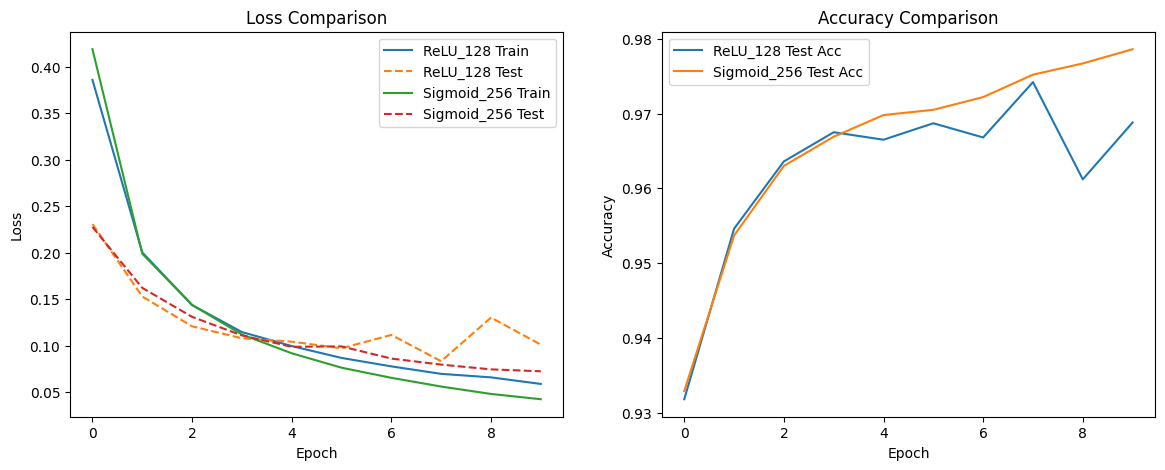

In [14]:
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
for exp in results:
    plt.plot(results[exp]["train_loss"], label=f"{exp} Train")
    plt.plot(results[exp]["test_loss"], linestyle='--', label=f"{exp} Test")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
for exp in results:
    plt.plot(results[exp]["test_acc"], label=f"{exp} Test Acc")
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [15]:
for exp in results:
    print(f"{exp} Final Test Accuracy: {results[exp]['test_acc'][-1]*100:.2f}%")

ReLU_128 Final Test Accuracy: 96.88%
Sigmoid_256 Final Test Accuracy: 97.86%
